<a href="https://colab.research.google.com/github/durvanshi/NNDL/blob/main/NNDL_practical04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Information
	
Training images : (60000, 28, 28)
Training labels : (60000,)
Testing images : (10000, 28, 28)
Testing labels : (10000,)
Number of classes: 10


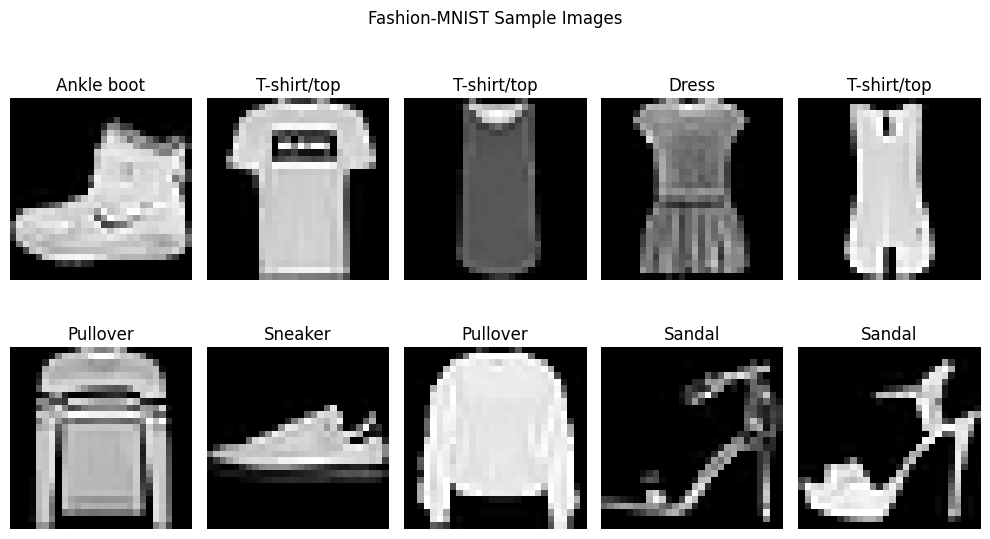


Image Information
	
Image size : (28, 28)
Pixel value : 0 to 1 after normalization

After Reshaping
	
Training images : (60000, 28, 28, 1)
Testing images : (10000, 28, 28, 1)

CNN Model Information
	


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


Model compiled successfully.

Training CNN Model
	
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 51s 57ms/step - accuracy: 0.8122 - loss: 0.5202 - val_accuracy: 0.8642 - val_loss: 0.3757
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 58ms/step - accuracy: 0.8776 - loss: 0.3398 - val_accuracy: 0.8835 - val_loss: 0.3167
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.8935 - loss: 0.2938 - val_accuracy: 0.8875 - val_loss: 0.3020
Epoch 4/5
 67/844 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step - accuracy: 0.8954 - loss: 0.2863

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load Fashion-MNIST Dataset
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data() # 2. Class Names
class_names = [ 'T-shirt/top', 'Trouser', 'Pullover', 'Dress',
'Coat',
'Sandal',
'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# 3. Display Dataset Information

print("Dataset Information")
print("	")
print("Training images :", x_train.shape)
print("Training labels :", y_train.shape)
print("Testing images :", x_test.shape)
print("Testing labels :", y_test.shape)
print("Number of classes:", len(class_names))

# 4. Display Sample Images
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.suptitle("Fashion-MNIST Sample Images")
plt.tight_layout()
plt.show()
# 5. Normalize Image Data

x_train = x_train / 255.0
x_test = x_test / 255.0

print("\nImage Information")
print("	")
print("Image size :", x_train.shape[1:])
print("Pixel value : 0 to 1 after normalization")

# 6. Reshape Images for CNN

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("\nAfter Reshaping")
print("	")
print("Training images :", x_train.shape)
print("Testing images :", x_test.shape)

# 7. Build CNN Model
model = models.Sequential([
    # Input layer
    layers.Input(shape=(28, 28, 1)),

    # First Convolution Layer
    layers.Conv2D(32, (3, 3), activation='relu'),

    # First Pooling Layer
    layers.MaxPooling2D((2, 2)),

    # Second Convolution Layer
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Second Pooling Layer
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps to 1D
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(64, activation='relu'),

    # Output Layer
    # 10 neurons = 10 classes
    layers.Dense(10, activation='softmax')
])

# 8. Display CNN Model Information

print("\nCNN Model Information")
print("	")

model.summary()
# 9. Compile Model
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy', metrics=['accuracy']
)
print("\nModel compiled successfully.")
# 10. Train CNN Model
print("\nTraining CNN Model")
print("	")

history = model.fit( x_train,
y_train, epochs=5, batch_size=64,
validation_split=0.1
)

# 11. Training Information

print("\nTraining Information")
print("	")

print(
"Final Training Accuracy :", history.history['accuracy'][-1]
)

print(
"Final Validation Accuracy :", history.history['val_accuracy'][-1]
)

print(
"Final Training Loss :", history.history['loss'][-1]
)

print(
"Final Validation Loss :", history.history['val_loss'][-1]
)

# 12. Plot Training and Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(
history.history['accuracy'], label='Training Accuracy'
)

plt.plot(
history.history['val_accuracy'], label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

# 13. Plot Training and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(
history.history['loss'], label='Training Loss'
)

plt.plot(
history.history['val_loss'], label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()
# 14. Evaluate Model on Test Dataset
test_loss, test_accuracy = model.evaluate(
x_test, y_test,
verbose=0
)

print("\nTest Information")
print("	")

print("Test Loss\t:", test_loss)
print("Test Accuracy :", test_accuracy)

print(
"Test Accuracy (%):", round(test_accuracy * 100, 2), "%"
)
# 15. Make Predictions
y_prediction = model.predict(
x_test, verbose=0
)

# Get class with highest probability
y_pred = np.argmax(
y_prediction, axis=1
)
# 16. Confusion Matrix
cm = confusion_matrix(
y_test, y_pred
)
plt.figure(figsize=(10, 8))
sns.heatmap(
cm, annot=True, fmt='d',
cmap='Blues', xticklabels=class_names, yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

# 17. Classification Report

print("\nClassification Report")
print("	")

print(
classification_report( y_test,
y_pred, target_names=class_names
)
)

# 18. Image Identification
index = 100
# Select image
image = x_test[index]

# Predict image
prediction = model.predict(
image.reshape(1, 28, 28, 1), verbose=0
)

# Get predicted class
predicted_class = np.argmax(
prediction
)
# Get confidence
confidence = prediction[0][predicted_class] * 100

print("\nImage Identification")
print("	")

print(
"Actual Class\t:", class_names[y_test[index]]
)

print(
"Predicted Class :", class_names[predicted_class]
)

print(
"Confidence\t:", round(confidence, 2), "%"
)

# 19. Display Identified Image
plt.figure(figsize=(5, 5))
plt.imshow(
image.reshape(28, 28), cmap='gray'
)

plt.title(
"Actual: " + class_names[y_test[index]]
+ "\nPredicted: " + class_names[predicted_class]
)

plt.axis('off')
plt.show()